<a href="https://colab.research.google.com/github/manuellazarte/TP-Mineria-Datos-Pinguinos/blob/main/TP1_Lazarte_Larrubia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico N°1 - Minería de Datos:

> **Año:** 2026  
> **Integrantes:**  
> * Larrubia, Agustín.  
> * Lazarte, Manuel.


## Introducción:
&emsp;El trabajo que se encuentra a continuación tiene como objetivo utilizar los conocimientos adquiridos en las Unidades 2 y 3 de la materia en el dataset 'penguins_size.csv' el cual contiene datos sobre distintas especies de pingüinos.

## Creación de ambiente e importación de dependencias:


In [96]:
# Manejo de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import plotly.express as px
import seaborn as sns

# Preparación de datos
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

## Adquisición y preparación de los datos:

In [97]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Lectura :

In [98]:
#file_path = 'penguins_size.csv' #Agus
file_path = '/content/drive/MyDrive/FCEIA/Minería de datos/TPs/TP1/penguins_size.csv' #Manu

df = pd.read_csv(file_path, sep=';')

### Analisis de la estructura de los datos:

&emsp;Realizamos el debido analisis de la estructura y contenido del dataset para ver detalles sobre su información general: cantidad de filas (muestras), nombre y tipo de dato de los atributos, cantidad de valores no nulos.

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 347 entries, 0 to 346
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Especie                  347 non-null    object 
 1   Longitud Culmen (mm)     345 non-null    float64
 2   Profundidad Culmen (mm)  345 non-null    float64
 3   Longitud Aleta (mm)      345 non-null    float64
 4   Masa corporal (g)        345 non-null    float64
 5   Sexo                     337 non-null    object 
 6   Unnamed: 6               0 non-null      float64
 7   Unnamed: 7               0 non-null      float64
dtypes: float64(6), object(2)
memory usage: 21.8+ KB


In [100]:
display(df.head())

,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo,Unnamed: 6,Unnamed: 7
0,Adelie Penguin,39.1,18.7,181.0,3750.0,MALE,NaN,NaN
1,Adelie Penguin,39.5,17.4,186.0,3800.0,FEMALE,NaN,NaN
2,Adelie Penguin,40.3,18.0,195.0,3250.0,FEMALE,NaN,NaN
3,Adelie Penguin,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Adelie Penguin,36.7,19.3,193.0,3450.0,FEMALE,NaN,NaN


### Limpieza de datos:

&emsp;Como se pudo observar en el paso anterior hay dos atributos \(columnas) que no cuentan con nombre y tampoco poseen contenido alguno \(0 non-null) por lo que procedemos a su eliminación, como tambien para todo registro \(fila) que no posea medidas aunque si tenga especificada la especie.

In [101]:
df = df.dropna(axis=1, how='all')
df = df.dropna(subset=df.columns.drop('Especie'), how='all')

&emsp;Luego de eliminar las columnas completamente vacías y las filas que no contienen información en ninguna de las variables más alla de la especie, se verifica nuevamente la estructura del dataset.

In [102]:
display(df.head())

,Especie,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g),Sexo
0,Adelie Penguin,39.1,18.7,181.0,3750.0,MALE
1,Adelie Penguin,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie Penguin,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie Penguin,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie Penguin,39.3,20.6,190.0,3650.0,MALE


In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 345 entries, 0 to 346
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Especie                  345 non-null    object 
 1   Longitud Culmen (mm)     345 non-null    float64
 2   Profundidad Culmen (mm)  345 non-null    float64
 3   Longitud Aleta (mm)      345 non-null    float64
 4   Masa corporal (g)        345 non-null    float64
 5   Sexo                     337 non-null    object 
dtypes: float64(4), object(2)
memory usage: 18.9+ KB


In [104]:
#excluimos Especie y Sexo
X = df.drop(['Especie', 'Sexo'], axis=1)

#almacenamos para colorear el grafico mas adelante
y_especie = df['Especie']
y_sexo = df['Sexo']

display(X)

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g)
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
4,36.7,19.3,193.0,3450.0
5,39.3,20.6,190.0,3650.0
...,...,...,...,...
341,47.2,13.7,214.0,4925.0
343,46.8,14.3,215.0,4850.0
344,50.4,15.7,222.0,5750.0
345,45.2,14.8,212.0,5200.0


## Análisis exploratorio

In [105]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 345 entries, 0 to 346
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Longitud Culmen (mm)     345 non-null    float64
 1   Profundidad Culmen (mm)  345 non-null    float64
 2   Longitud Aleta (mm)      345 non-null    float64
 3   Masa corporal (g)        345 non-null    float64
dtypes: float64(4)
memory usage: 13.5 KB


In [106]:
y_sexo = y_sexo.to_frame()

In [107]:
y_sexo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 345 entries, 0 to 346
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Sexo    337 non-null    object
dtypes: object(1)
memory usage: 5.4+ KB


In [108]:
y_sexo.value_counts(dropna=False)

,count
Sexo,
MALE,170
FEMALE,166
NaN,8
.,1


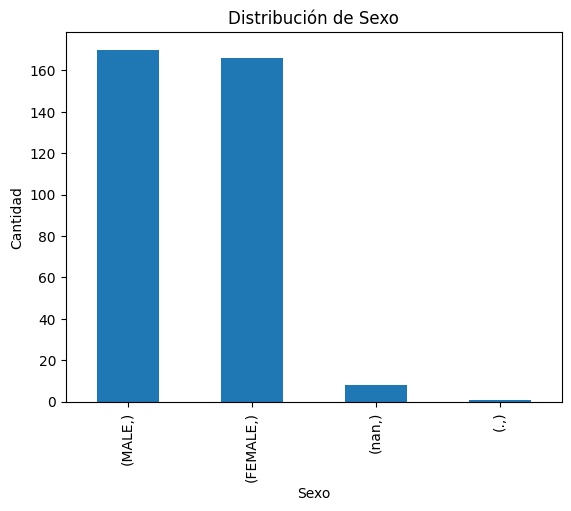

In [109]:
y_sexo.value_counts(dropna=False).plot(kind="bar")

plt.xlabel("Sexo")
plt.ylabel("Cantidad")
plt.title("Distribución de Sexo")
plt.show()

In [110]:
imputer = SimpleImputer(strategy="most_frequent").set_output(transform="pandas")
y_sexo = imputer.fit_transform(y_sexo)

In [111]:
y_sexo.value_counts(dropna=False)

,count
Sexo,
MALE,178
FEMALE,166
.,1


Observamos la correlación entre atributos

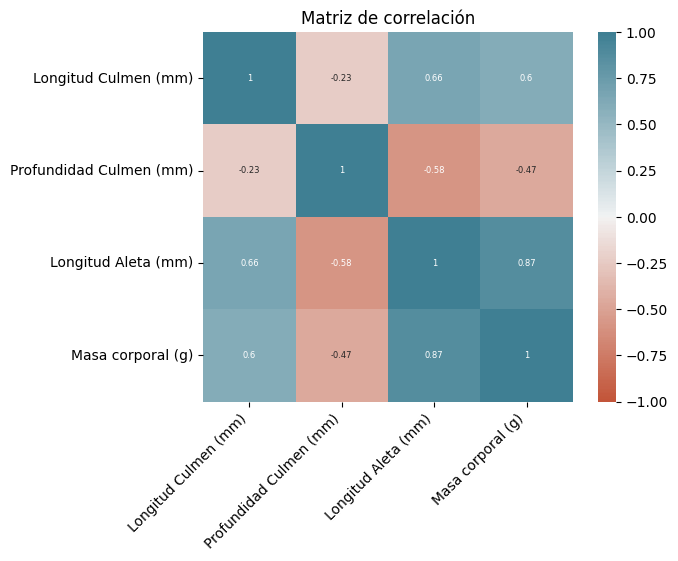

In [112]:
corr = X.corr()
ax = sns.heatmap(corr,vmin=-1, vmax=1, center=0, cmap=sns.diverging_palette(20, 220, n=200), square=True, annot = True, annot_kws = {'size': 6})
ax.set_xticklabels(ax.get_xticklabels(), rotation=45,horizontalalignment='right')
plt.title('Matriz de correlación')
plt.show()

Se observa una correlación positiva fuerte entre `Longitud Aleta (mm)` y `Masa corporal (g)`, moderada entre `Longitud Culmen (mm)` - `Masa corporal (g)` y `Longitud culmen (mm)` - `Longitud Aleta (mm)`
Al mismo tiempo también se puede ver una correlación negativa moderada entre `Profundidad Culmen (mm)` - `Masa corporal (g)` y `Profundida Culmen (mm)` - `Longitud Aleta (mm)`

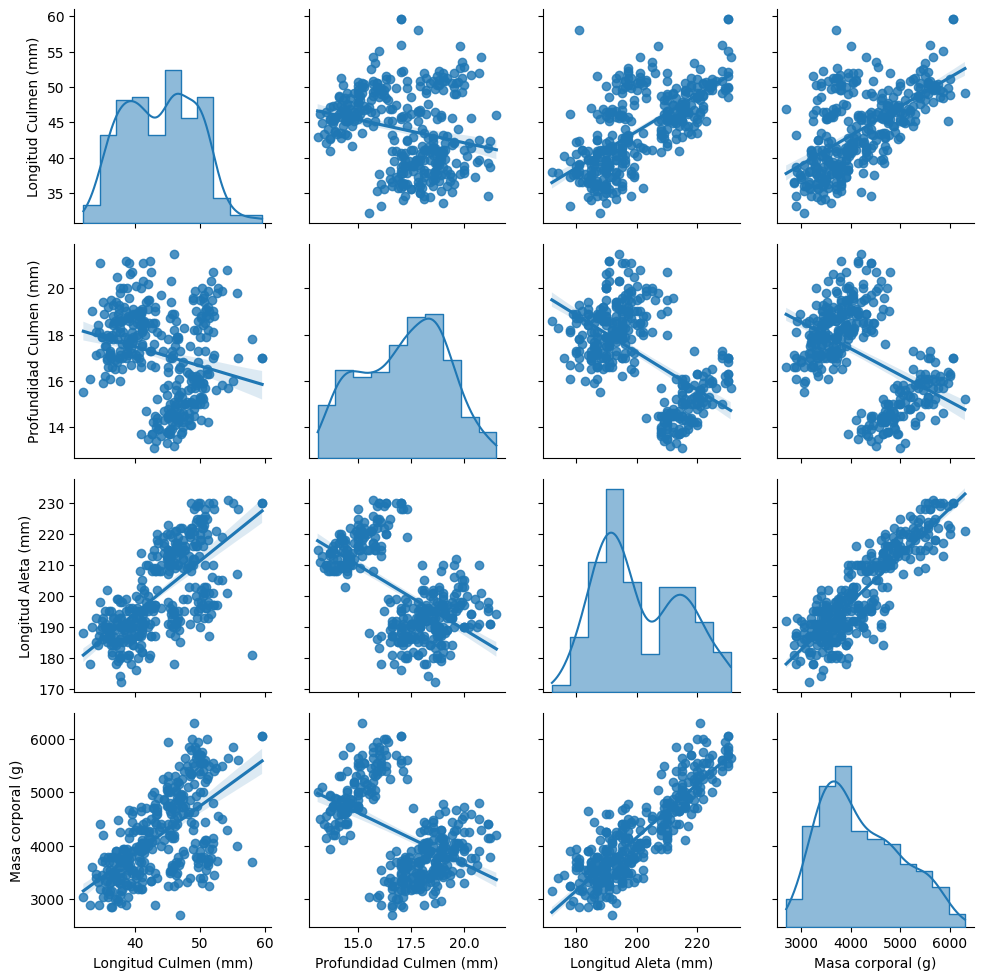

In [113]:
g = sns.PairGrid(X)
g.map_diag(sns.histplot, kde=True, element='step')
g.map_offdiag(sns.regplot)

En los scatterplots se observan relaciones positivas entre Longitud Culmen (mm), Longitud Aleta (mm) y Masa corporal (g), siendo especialmente marcada la relación entre Longitud Aleta (mm) y Masa corporal (g). Por otro lado, Profundidad Culmen (mm) presenta relaciones negativas con las otras tres variables. En varias de estas relaciones se observan agrupamientos diferenciados de los datos, en lugar de una única distribución continua.

Así mismo, En la diagonal se observan las distribuciones individuales de las cuatro variables. Longitud Culmen (mm) presenta una distribución relativamente extendida, con cierta concentración de valores en dos zonas. Profundidad Culmen (mm) también muestra dos concentraciones diferenciadas. Longitud Aleta (mm) presenta una bimodalidad marcada, con un grupo de valores alrededor de 185–200 mm y otro cercano a 210–225 mm. Masa corporal (g) presenta asimismo una distribución bimodal, con una concentración en torno a 3000–4000 g y otra en valores superiores.

### Normalización:

&emsp;Como se observa en la estructura de arriba tenemos variables que poseen distintas escalas como por ejemplo Longitud Culmen, Profundidad Culmen y Longitud aleta en milimetros contra Masa corporal que esta en gramos y ademas de escalas poseen distinto ordenes de magnitud, por lo que es necesario normalizar estas variables para hacer que todas contribuyan de forma equitativa al análisis, evitando que la Masa Corporal domine los resultados simplemente por tener valores numericos más grandes

In [114]:
scaler = StandardScaler().set_output(transform="pandas")
X_scaled = scaler.fit_transform(X)
X_scaled.describe()

,Longitud Culmen (mm),Profundidad Culmen (mm),Longitud Aleta (mm),Masa corporal (g)
count,3.450000e+02,3.450000e+02,3.450000e+02,3.450000e+02
mean,4.942906e-16,8.650085e-16,-1.647635e-16,-1.647635e-16
std,1.001452e+00,1.001452e+00,1.001452e+00,1.001452e+00
min,-2.152715e+00,-2.064401e+00,-2.054922e+00,-1.868158e+00
25%,-8.622873e-01,-7.916735e-01,-7.770266e-01,-8.123403e-01
50%,8.281498e-02,7.378131e-02,-2.800670e-01,-1.912713e-01
75%,8.279918e-01,7.865088e-01,8.558404e-01,6.782254e-01
max,2.845422e+00,2.211964e+00,2.133736e+00,2.603539e+00
